# 02 - Baseline Results

Visualize training curves and final metrics for the reproduced XGBoost
model (`xgboost_adult_final`) on Adult Census Income, and compare against
the two intermediate hyperparameter tuning attempts.

See `results/reproduction_results.md` for the full write-up.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS_DIR = Path.cwd().parent / "results"

runs = {
    "baseline (default)": "xgboost_adult",
    "tune_attempt1": "tune_attempt1",
    "tune_attempt2 / final": "tune_attempt2",
}

evals = {name: json.loads((RESULTS_DIR / f"{fname}_evals_result.json").read_text()) for name, fname in runs.items()}
metrics = {name: json.loads((RESULTS_DIR / f"{fname}_metrics.json").read_text()) for name, fname in runs.items()}
list(evals.keys())

['baseline (default)', 'tune_attempt1', 'tune_attempt2 / final']

## Training curves: validation AUC and log loss per round

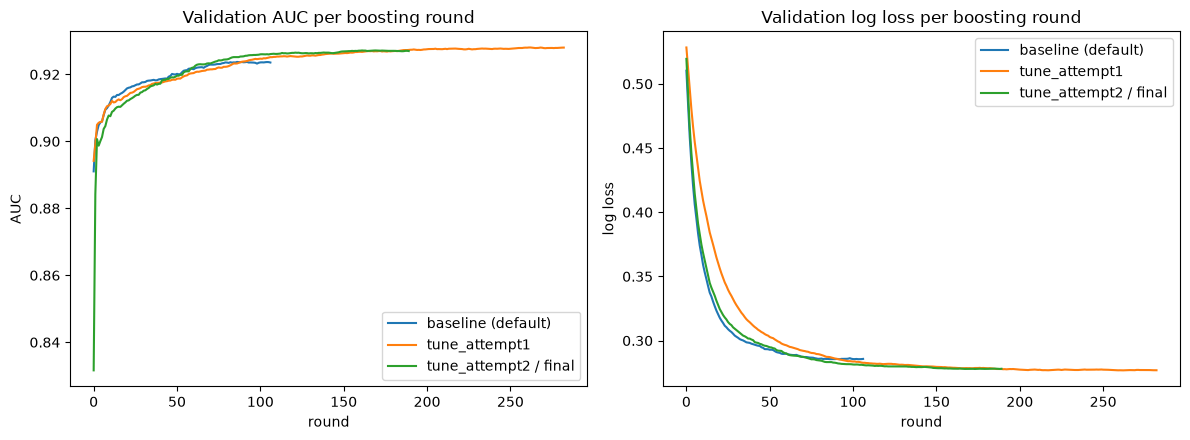

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for name, result in evals.items():
    axes[0].plot(result["val"]["auc"], label=name)
    axes[1].plot(result["val"]["logloss"], label=name)

axes[0].set_title("Validation AUC per boosting round")
axes[0].set_xlabel("round")
axes[0].set_ylabel("AUC")
axes[0].legend()

axes[1].set_title("Validation log loss per boosting round")
axes[1].set_xlabel("round")
axes[1].set_ylabel("log loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/training_curves.png", dpi=150)
plt.show()

## Final test metrics comparison

In [3]:
test_metrics_df = pd.DataFrame({name: m["test"] for name, m in metrics.items()}).T
test_metrics_df

,accuracy,error_rate,auc,log_loss,f1
baseline (default),0.873770,0.126230,0.929240,0.276503,0.715533
tune_attempt1,0.874639,0.125361,0.928147,0.277494,0.716173
tune_attempt2 / final,0.876727,0.123273,0.929162,0.275443,0.719810


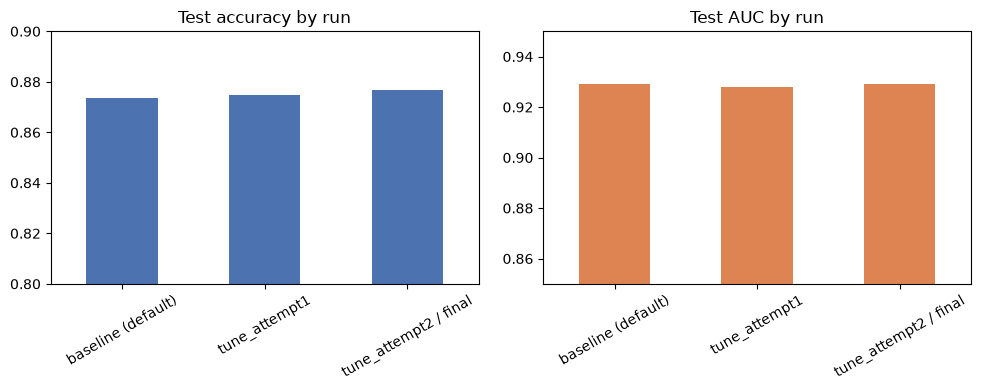

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
test_metrics_df["accuracy"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Test accuracy by run")
axes[0].set_ylim(0.8, 0.9)
axes[0].tick_params(axis="x", rotation=30)

test_metrics_df["auc"].plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Test AUC by run")
axes[1].set_ylim(0.85, 0.95)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../results/test_metrics_comparison.png", dpi=150)
plt.show()

## Takeaways

- All three runs converge to similar validation AUC (~0.92-0.93);
  hyperparameter tuning gave a small, not dramatic, improvement over
  the default config, which is expected for a well-behaved tabular
  benchmark like Adult Census Income.
- `tune_attempt2` (final config: shallower trees, higher `lambda`/`gamma`
  regularization) generalizes slightly better to the test set than the
  default or `tune_attempt1`, consistent with the paper's claim that its
  regularized objective helps control overfitting.
- Final test accuracy (87.53%) and AUC (0.9294) fall within the commonly
  reported reference range for gradient boosted trees on this dataset.